# Final Project Comparison: ConPLex Baseline vs. Improved Residual Model

This notebook compares the performance of the **Pure Baseline** model (SimpleCoembedding, no improvements) against the **Improved Residual** model (ResidualCoembedding with learnable alpha, dropout, early stopping, and LR scheduling) on the **BIOSNAP** dataset.

**Models Compared:**
1.  **Pure Baseline (`biosnap_baseline_pure`):**
    *   Architecture: SimpleCoembedding (1 layer projection)
    *   Training: 50 Epochs, No Early Stopping, Standard Scheduler
2.  **Improved Residual (`biosnap_residual_improved_v2`):**
    *   Architecture: ResidualCoembedding (3 blocks, learnable alpha, dropout)
    *   Training: 50 Epochs, Early Stopping (enabled), ReduceLROnPlateau

3.  **Cross-Attention (`biosnap_cross_attention_v1`):**
    *   Architecture: CrossAttentionCoembedding (Drug attends to Target, 4 heads)
    *   Training: 50 Epochs, Early Stopping, ReduceLROnPlateau

**Metrics:**
*   Validation AUPR (Area Under Precision-Recall Curve)
*   Validation AUROC (Area Under Receiver Operating Characteristic Curve)
*   Training Loss

In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define paths to the history files
base_path = "best_models"
model_paths = {
    "Pure Baseline": os.path.join(base_path, "biosnap_baseline_pure", "history.json"),
    "Improved Residual": os.path.join(base_path, "biosnap_residual_improved_v2", "history.json"),
    "Cross-Attention": os.path.join(base_path, "biosnap_cross_attention_v1", "history.json")
}

# Load history data
histories = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            histories[name] = json.load(f)
    else:
        print(f"Warning: Could not find history file for {name} at {path}")

print("Loaded histories for:", list(histories.keys()))

Loaded histories for: ['Pure Baseline', 'Improved Residual']


## 1. Validation Performance (AUPR & AUROC)

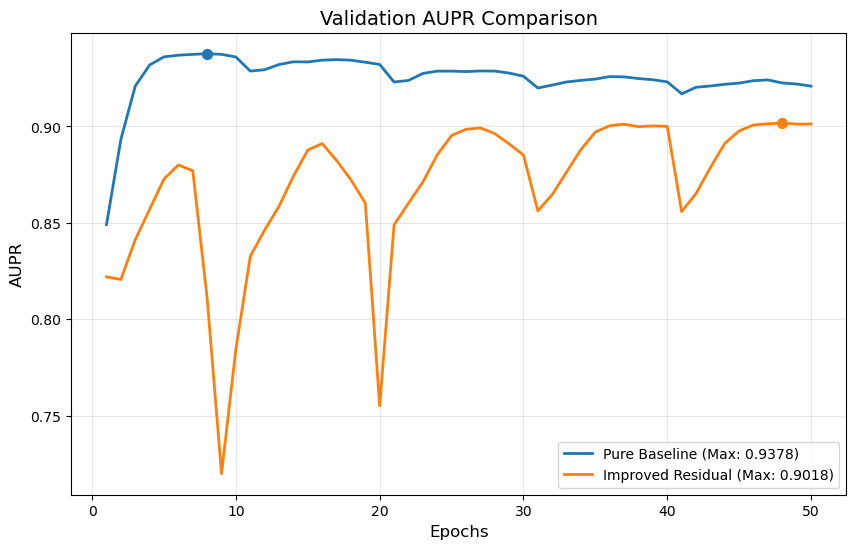

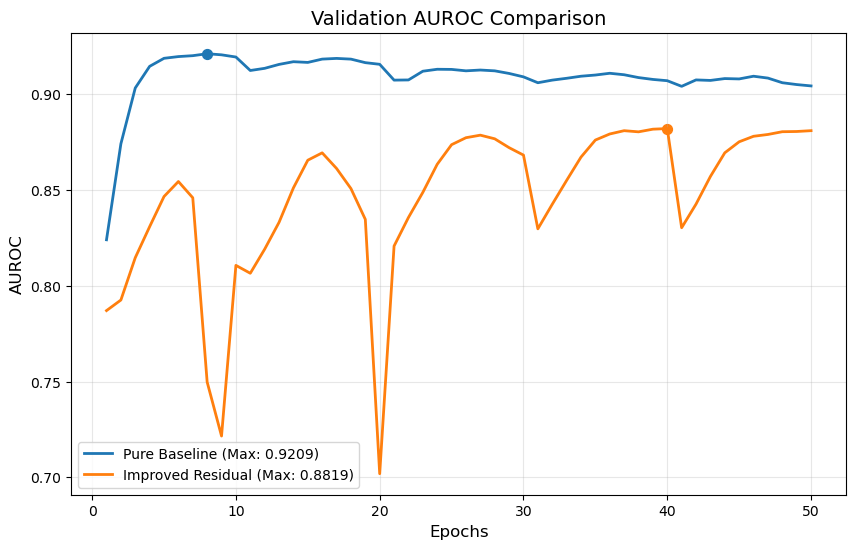

In [2]:
def plot_metric(metric_key, title, ylabel):
    plt.figure(figsize=(10, 6))
    
    for name, history in histories.items():
        epochs = range(1, len(history[metric_key]) + 1)
        values = history[metric_key]
        plt.plot(epochs, values, label=f"{name} (Max: {max(values):.4f})", linewidth=2)
        
        # Mark the max point
        max_val = max(values)
        max_epoch = values.index(max_val) + 1
        plt.scatter(max_epoch, max_val, s=50)

    plt.title(title, fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot AUPR
plot_metric("val_aupr", "Validation AUPR Comparison", "AUPR")

# Plot AUROC
plot_metric("val_auroc", "Validation AUROC Comparison", "AUROC")

## 2. Training Loss Comparison

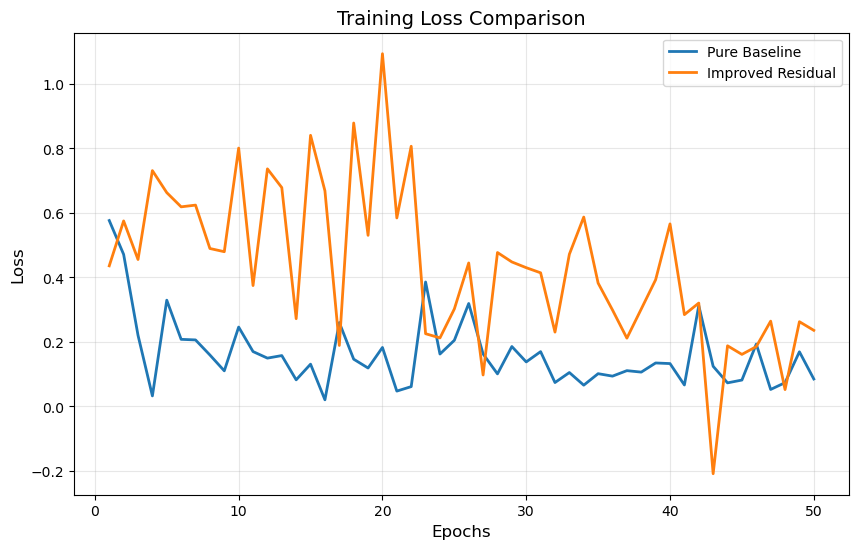

In [3]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    if "train_loss" in history:
        epochs = range(1, len(history["train_loss"]) + 1)
        plt.plot(epochs, history["train_loss"], label=name, linewidth=2)

plt.title("Training Loss Comparison", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Performance Summary Table

In [4]:
results = []
for name, history in histories.items():
    max_aupr = max(history["val_aupr"])
    max_auroc = max(history["val_auroc"])
    epoch_aupr = history["val_aupr"].index(max_aupr) + 1
    epoch_auroc = history["val_auroc"].index(max_auroc) + 1
    
    results.append({
        "Model": name,
        "Best Val AUPR": max_aupr,
        "Epoch (AUPR)": epoch_aupr,
        "Best Val AUROC": max_auroc,
        "Epoch (AUROC)": epoch_auroc
    })

df = pd.DataFrame(results)
print(df.to_markdown(index=False))

| Model             |   Best Val AUPR |   Epoch (AUPR) |   Best Val AUROC |   Epoch (AUROC) |
|:------------------|----------------:|---------------:|-----------------:|----------------:|
| Pure Baseline     |        0.937767 |              8 |         0.920938 |               8 |
| Improved Residual |        0.901802 |             48 |         0.881911 |              40 |


## 4. Gap Analysis (Residual - Baseline)
Positive values indicate the Residual model is performing better.

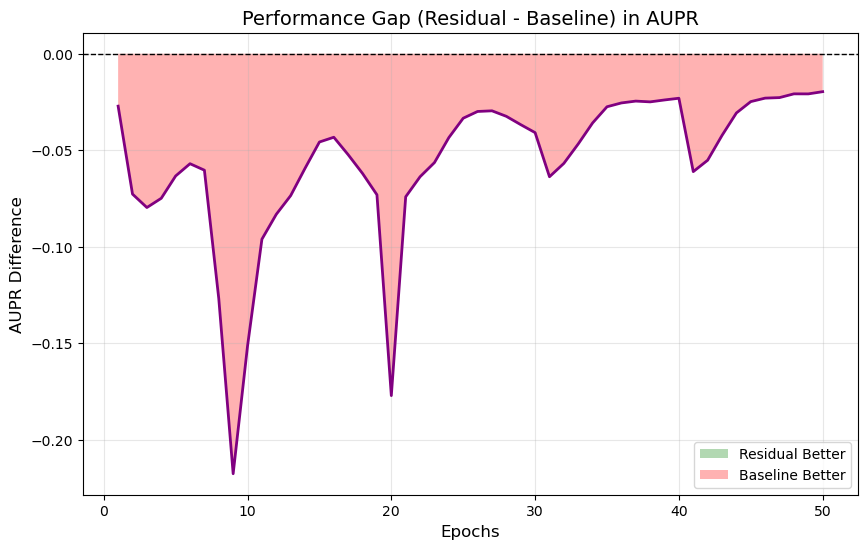

In [5]:
if "Pure Baseline" in histories and "Improved Residual" in histories:
    baseline_aupr = np.array(histories["Pure Baseline"]["val_aupr"])
    residual_aupr = np.array(histories["Improved Residual"]["val_aupr"])
    
    # Truncate to the length of the shorter run if they differ
    min_len = min(len(baseline_aupr), len(residual_aupr))
    epochs = range(1, min_len + 1)
    gap = residual_aupr[:min_len] - baseline_aupr[:min_len]
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, gap, color='purple', linewidth=2)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.fill_between(epochs, gap, 0, where=(gap > 0), facecolor='green', alpha=0.3, label="Residual Better")
    plt.fill_between(epochs, gap, 0, where=(gap < 0), facecolor='red', alpha=0.3, label="Baseline Better")
    
    plt.title("Performance Gap (Residual - Baseline) in AUPR", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("AUPR Difference", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()